<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/05_autoregressive/03_pixelcnn_md/pixelcnn_md-project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👾 PixelCNN using Tensorflow distributions

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions

In [17]:
import numpy as np

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import os


In [27]:
import matplotlib.pyplot as plt


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## 0. Parameters <a name="parameters"></a>

In [19]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 10
BATCH_SIZE = 128

## 1. Prepare the data <a name="prepare"></a>

In [20]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

In [21]:
# Preprocess the data


def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs


input_data = preprocess(x_train)

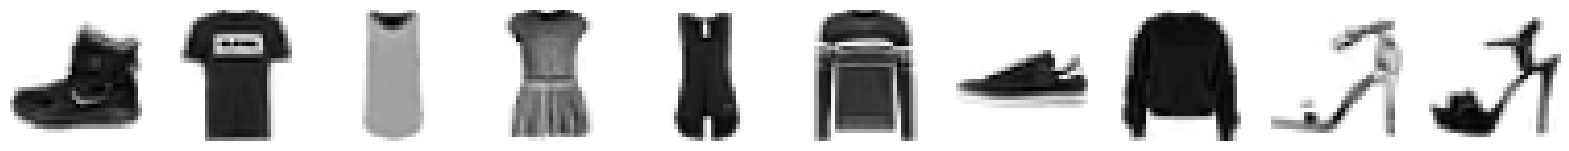

In [22]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [23]:
# Define a custom Keras Layer to wrap the log_prob computation
class LogProbLayer(layers.Layer):
    def __init__(self, distribution, **kwargs):
        super(LogProbLayer, self).__init__(**kwargs)
        self.distribution = distribution

    def call(self, inputs):
        return self.distribution.log_prob(inputs)

# Define a Keras Layer to wrap tf.reduce_mean
class MeanLayer(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs)

# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Define the model input
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# Get the log likelihood using the custom layer
log_prob_output = LogProbLayer(dist, name="log_prob_output")(image_input)

# Compute the mean of the log likelihood using the custom MeanLayer for the loss
mean_log_prob_output = MeanLayer(name="mean_log_prob_output")(log_prob_output)

# Define the model
pixelcnn = models.Model(inputs=image_input, outputs=log_prob_output)
# pixelcnn.add_loss(-mean_log_prob_output) # Removed due to NotImplementedError


## 3. Train the PixelCNN <a name="train"></a>

In [24]:
# Compile and train the model
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
)

In [25]:
if not os.path.exists("logs"):
    os.makedirs("logs")

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_img,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )


img_generator_callback = ImageGenerator(num_img=2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/tensorboard.py:680: UserWarning: Model failed to serialize as JSON. Ignoring... 
Object LogProbLayer was created by passing
non-serializable argument values in `__init__()`,
and therefore the object must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:


class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config

  warnings.warn(f"Model failed to serialize as JSON. Ignoring... {exc}")
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4383.1393
Saved to ./output/generated_img_000.png


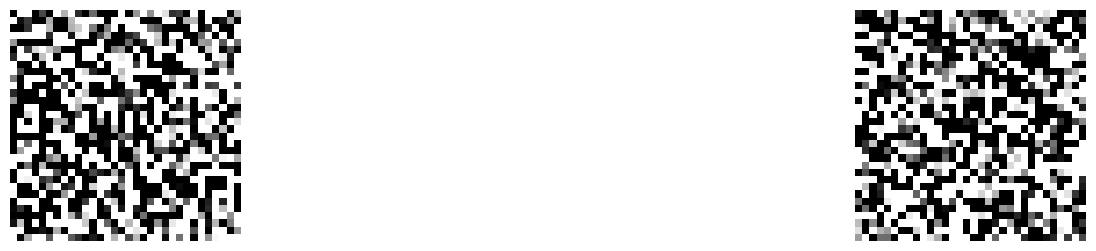

469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 282ms/step - loss: 4378.0762
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4382.6273
Saved to ./output/generated_img_001.png


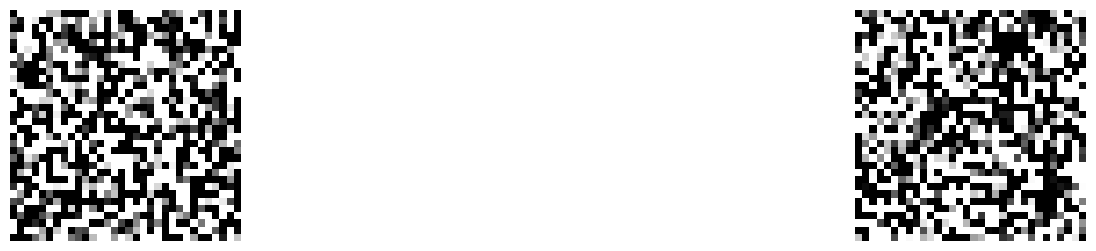

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 272ms/step - loss: 4378.0757
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4380.6779
Saved to ./output/generated_img_002.png


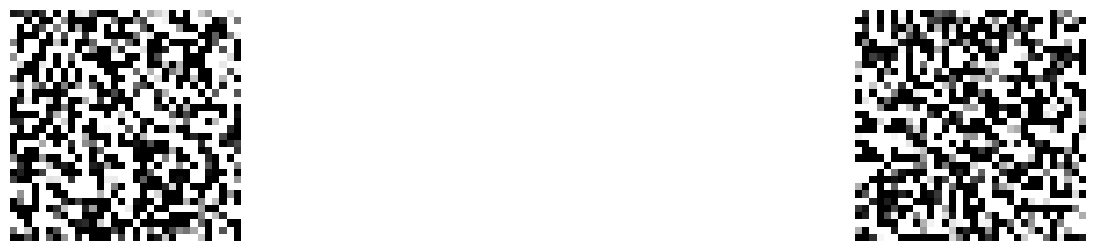

469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 270ms/step - loss: 4378.0771
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4376.5222
Saved to ./output/generated_img_003.png


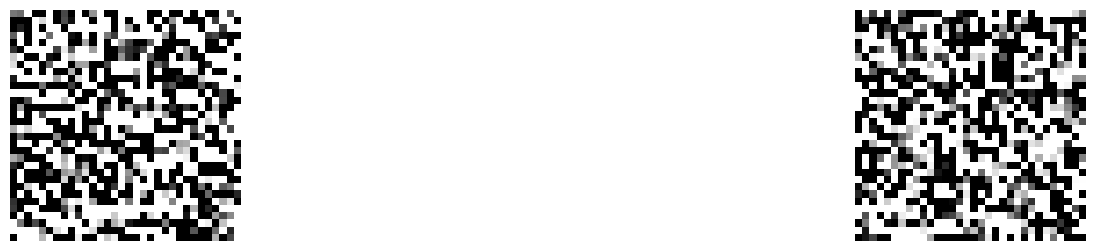

469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 265ms/step - loss: 4378.0776
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4380.8414
Saved to ./output/generated_img_004.png


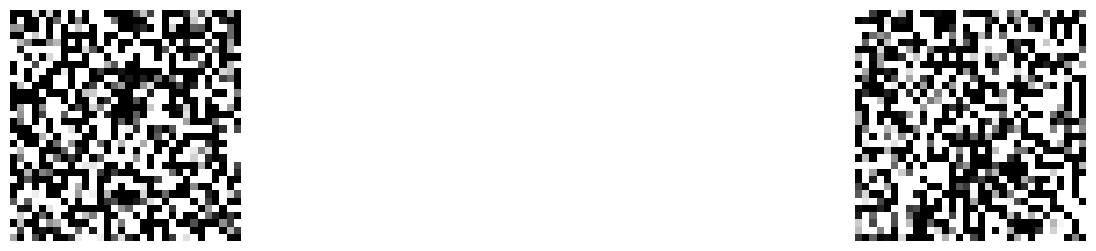

469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - loss: 4378.0791
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4379.2198
Saved to ./output/generated_img_005.png


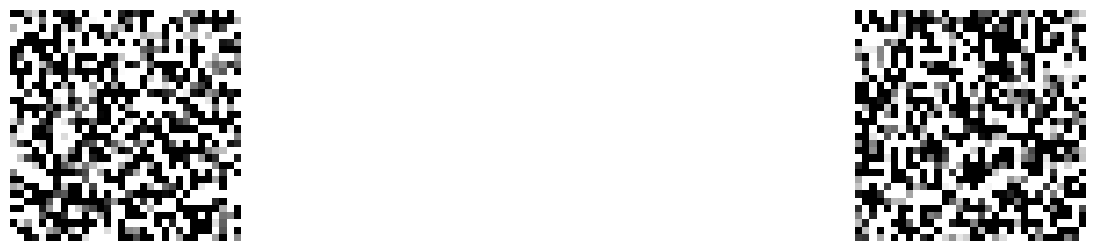

469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 265ms/step - loss: 4378.0767
Epoch 7/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4379.6039
Saved to ./output/generated_img_006.png


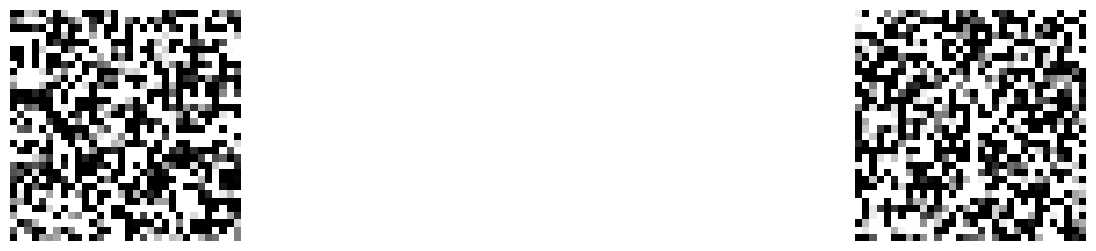

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 271ms/step - loss: 4378.0757
Epoch 8/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4375.4972
Saved to ./output/generated_img_007.png


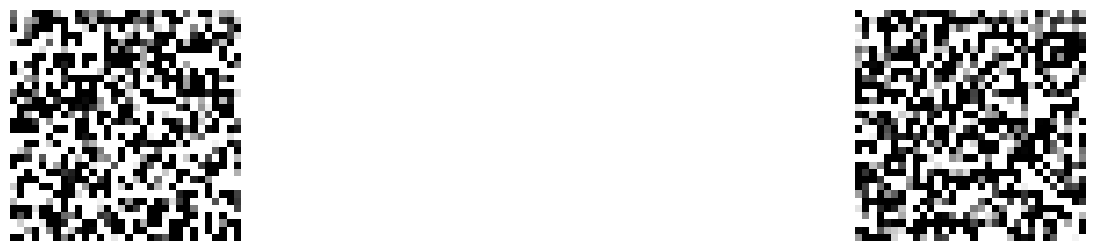

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 272ms/step - loss: 4378.0771
Epoch 9/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4376.8855
Saved to ./output/generated_img_008.png


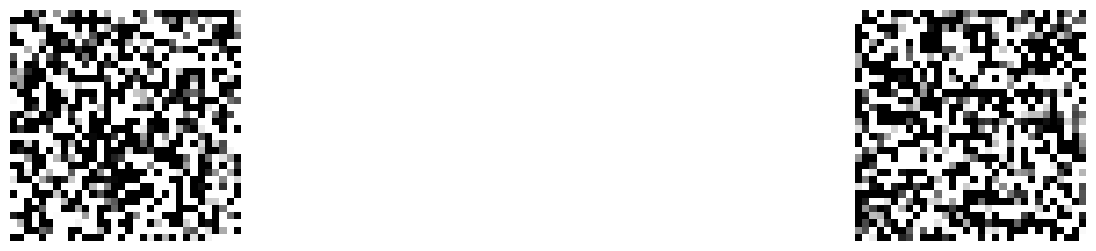

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 271ms/step - loss: 4378.0762
Epoch 10/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4374.0222
Saved to ./output/generated_img_009.png


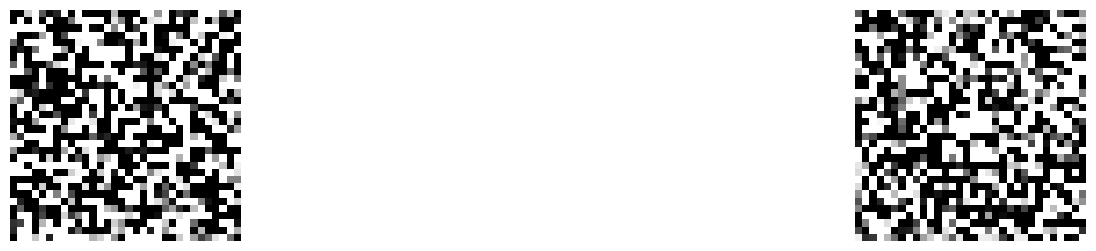

469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - loss: 4378.0762


In [26]:
# Recompile the model with a custom loss function
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
    loss=lambda y_true, y_pred: -tf.reduce_mean(y_pred)
)

# Train the model, passing input_data as both x and y
pixelcnn.fit(
    x=input_data,
    y=input_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)


## 4. Generate images <a name="generate"></a>

In [28]:
generated_images = img_generator_callback.generate()

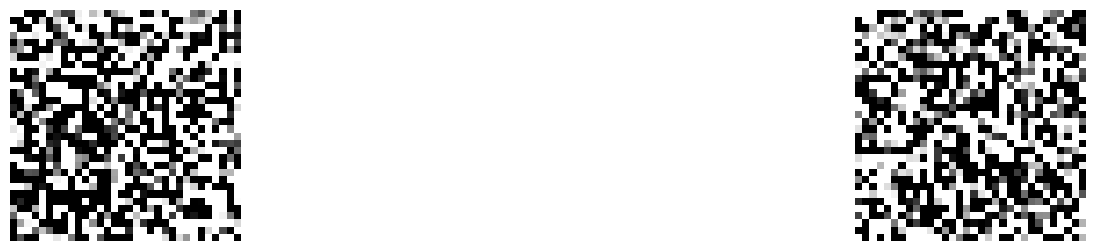

In [29]:
display(generated_images, n=img_generator_callback.num_img)